# CyberTwin Milestone 4: Digital Twin and Temporal Modeling

This notebook demonstrates the transition from a static, tabular IDS to a stateful Digital Twin network prototype using Temporal Deep Learning.

## 1. Important Academic Limitation (Dataset Chronology)

The dataset slice (`Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv`) completely omits the original `Timestamp`, `Flow ID`, and `Source/Destination IP` features. Because of this, we cannot reconstruct the true chronological flow of the network, nor can we trace exactly which physical machine originated a specific flow.

To proceed with temporal modeling and the Digital Twin simulation, we construct **synthetic temporal sequences** by applying a sliding window over the randomized dataset splits. The simulated sequences preserve the exact feature distributions of the original flows but represent a *synthetic chronology*.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import torch
from src.temporal_simulator import load_and_simulate
from src.models.temporal_bilstm import TemporalBiLSTM
from src.digital_twin import DigitalTwinNetwork, NodeState
from src.run_digital_twin import run_simulation, plot_digital_twin

import warnings
warnings.filterwarnings('ignore')

## 2. Load Processed Data and Generate Temporal Sequences
We generate fixed-length windows of `size=20`. A window is labeled an attack if *any* flow within it is an attack (Early-Warning paradigm).

In [2]:
train_data, val_data, test_data, manifest = load_and_simulate(data_dir='../data/processed', window_size=20, strategy='any', output_dir='../results/tables')
print("Manifest:")
print(json.dumps(manifest, indent=2))

Manifest:
{
  "sequence_length": 20,
  "feature_count": 70,
  "train_sequences": 14986,
  "validation_sequences": 3210,
  "test_sequences": 3210,
  "sequence_label_definition": "any",
  "random_seed": 42,
  "simulation_method": "Sliding window over random stratified splits (synthetic chronology)",
  "stride": 10
}


## 3. Train Temporal BiLSTM Model
*(Training happens via `src/train_temporal_model.py`. We will load the resulting metrics and plots here.)*

In [3]:
history_df = pd.read_csv('../results/metrics/temporal_model_training_history.csv')
print(f"Best Validation F1: {history_df['val_f1'].max():.4f}")
history_df.tail()

Best Validation F1: 0.9983


,epoch,train_loss,val_loss,train_f1,val_f1,val_acc,learning_rate,epoch_time
4,5,0.027374,0.022478,0.997994,0.998284,0.996573,0.0010,28.473860
5,6,0.026994,0.022259,0.997994,0.998284,0.996573,0.0010,62.122922
6,7,0.027498,0.022837,0.997994,0.998284,0.996573,0.0010,32.944719
7,8,0.026742,0.022649,0.997994,0.998284,0.996573,0.0005,34.655113
8,9,0.026012,0.022650,0.997994,0.998284,0.996573,0.0005,37.654309


## 4. Run Digital Twin Simulation
We load the trained model and run a stateful simulation over the test sequences. Three virtual nodes (`node_001`, `node_002`, `node_003`) are instantiated to manage dynamic state transitions (`NORMAL`, `SUSPICIOUS`, `UNDER_ATTACK`, `RECOVERING`).

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = TemporalBiLSTM(input_dim=70, hidden_dim=128, num_layers=2, dropout=0.3).to(device)
model.load_state_dict(torch.load('../results/temporal_model_best.pth', weights_only=True))
model.eval()

from src.temporal_dataset import TemporalDataset
from torch.utils.data import DataLoader
test_dataset = TemporalDataset(test_data[0], test_data[1])
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

log_df = run_simulation(model, test_loader, device=device, num_steps=1000)
log_df.head()

,simulation_step,node_id,traffic_volume,packet_count,attack_probability,risk_score,network_state,global_risk,true_sequence_label,update_latency_ms
0,0,node_001,4.000026e+12,1,0.996512,0.998256,UNDER_ATTACK,1.0,1.0,0.1015
1,1,node_002,1.864170e+00,1,0.996276,0.801866,UNDER_ATTACK,1.0,1.0,0.0505
2,2,node_003,2.786874e+00,1,0.996227,0.803687,UNDER_ATTACK,1.0,1.0,0.0358
3,3,node_001,4.000303e+12,2,0.997073,0.998537,UNDER_ATTACK,1.0,1.0,0.0517
4,4,node_002,6.424483e+04,2,0.996031,0.998015,UNDER_ATTACK,1.0,1.0,0.0387


## 5. Visualizing Network State and Risk


Simulation Latency Statistics (ms):
Mean: 0.0740 ms
Median: 0.0652 ms
95th Percentile: 0.1107 ms


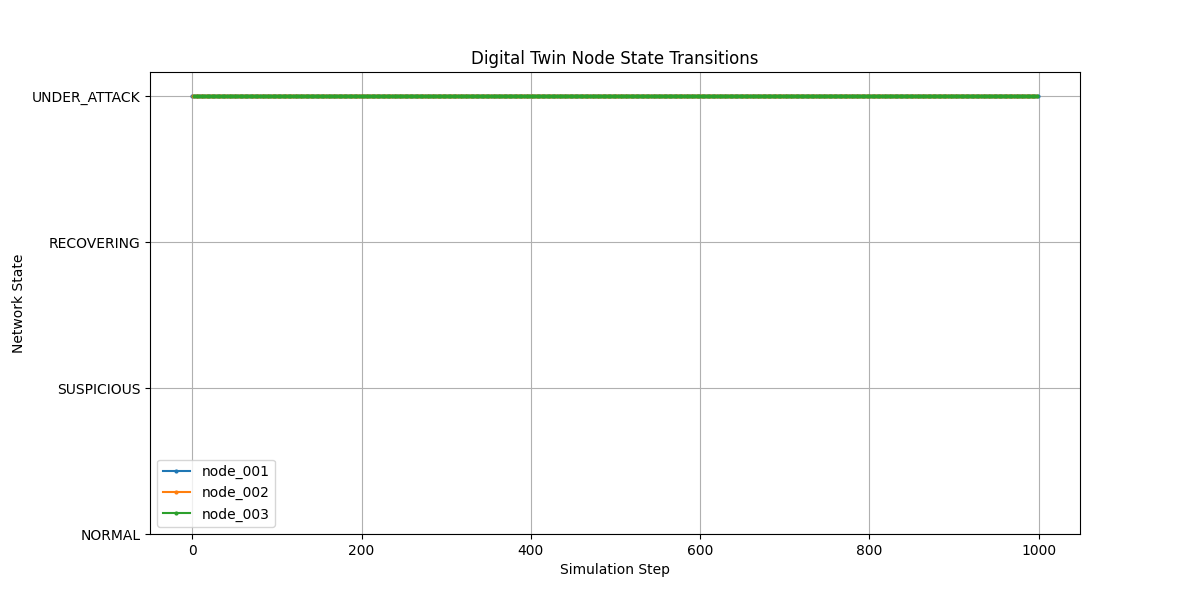

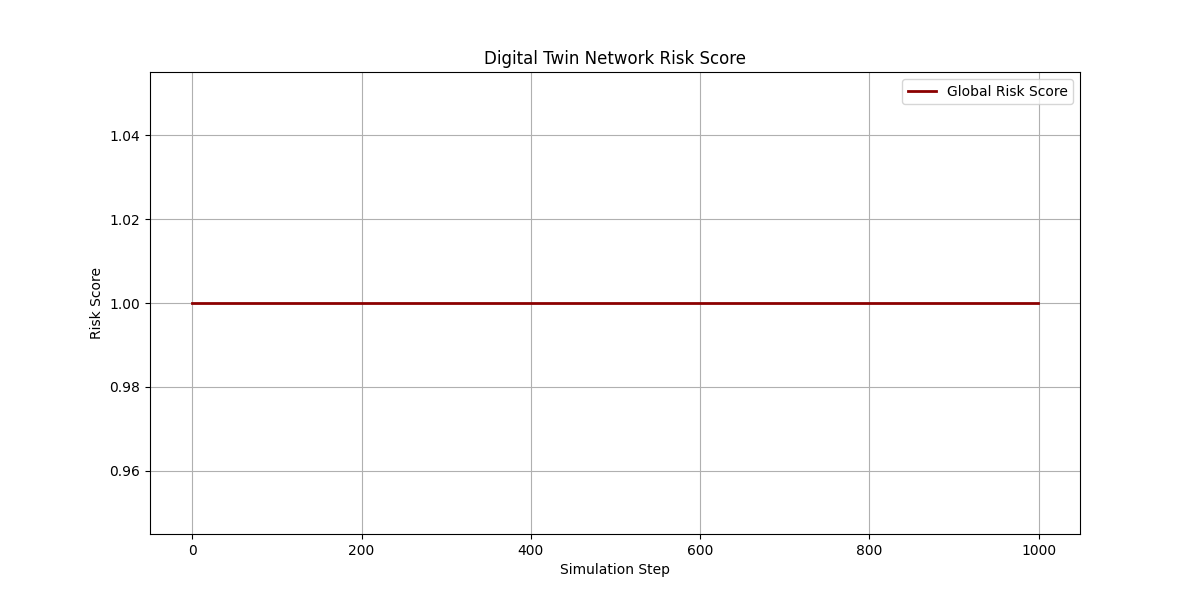

In [5]:
plot_digital_twin(log_df, output_dir='../results/figures')
from IPython.display import Image, display
display(Image(filename='../results/figures/network_state_transitions.png'))
display(Image(filename='../results/figures/network_risk_timeline.png'))

## 6. SHAP Explainability
We use SHAP (GradientExplainer) to determine which temporal features drive the BiLSTM's sequence-level predictions.

In [6]:
from src.explainability import temporal_explainability
sample_df = pd.read_csv('../data/processed/X_train.csv', nrows=1)
feature_names = sample_df.columns.tolist()
    
temporal_explainability(model, test_loader, feature_names, device=device, output_dir='../results/figures')


Running GradientExplainer with background shape torch.Size([50, 20, 70]) and test shape torch.Size([50, 20, 70])


SHAP Explainer failed: too many indices for tensor of dimension 1
Note: SHAP support for complex PyTorch RNNs is sometimes unreliable. Documenting limitation.
